## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Santiago Camacho Jimenez Andrés Felipe Vargas Gómez" # @param {"type":"string"}
carnet = 1000116319 # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**


Una empresa de mensajería cuenta con una red de distribución compuesta por varios centros de paquetes (A, B, C, D, E, F y G) interconectados por rutas terrestres de doble sentido (grafo no dirigido).

Con el fin de optimizar el rastreo de envíos, realizar inspecciones completas de rutas y planificar la expansión de su infraestructura, la empresa requiere un sistema de software que permita:  

- Representar la topología de la red mediante una lista de adyacencia.   
- Realizar recorridos de la red desde cualquier nodo de inicio utilizando los algoritmos de Búsqueda en Anchura (BFS) y Búsqueda en Profundidad (DFS).
- Determinar los niveles de proximidad de los centros respecto al nodo origen en BFS.   
- Buscar la ruta mínima en cantidad de conexiones entre un centro de origen y uno de destino utilizando BFS.   
- Agregar dinámicamente nuevos centros de distribución y conexiones.   

## 2) Requerimientos **[2 pts]**





Requerimientos Funcionales
- El sistema debe inicializar y mostrar la red de distribucion mediante una lista ad adyacencia no dirigida
- El sistema debe la Búsqueda en Anchura (BFS) desde un vértice inicial, indicando la secuencia de visita y clasificando cada centro por niveles de distancia
- El sistema debe ejecutar la Búsqueda en Profundidad (DFS) desde un vértice inicial, mostrando la secuencia completa de visita
- El usuario debe poder definir el centro inicial desde el cual se iniciarán los recorridos BFS y DFS
- El sistema debe permitir buscar la ruta de menor número de conexiones entre un nodo inicial y uno objetivo mediante BFS, devolviendo el camino exacto y el total de conexiones

Requerimientos No Funcionales
- El código debe ser claro, estructurado con funciones sencillas y fácil de entender
-

## 3) Historias de usuario **[2 pts]**



Historia de usuario 1
- Como usuario del sistema quiero ver como estan conectados los centros para conocer las rutas disponibles en la empresa

Historia de usuario 2
- Como usuario quiero ejecutar el recorrido BFS desde un centro inicial para ver los centros ordenados por cercania

Historia de usuario 3
- Como usuario quiero ingresar un punto de origen y un destino para conocer la ruta con menos conexiones y el total de paradas

Historia de usuario 4
- Como usuario quiero ejecutar el recorrido DFS desde un centro inicial para explorar una ruta completa hasta el final antes de regresar

Historia de usuario 5
- como usuario quiero agregar un centro nuevo conectandolo con los existentes para actualizar la red de distribucion

## 4) Diagramas de flujo **[5 pts]**

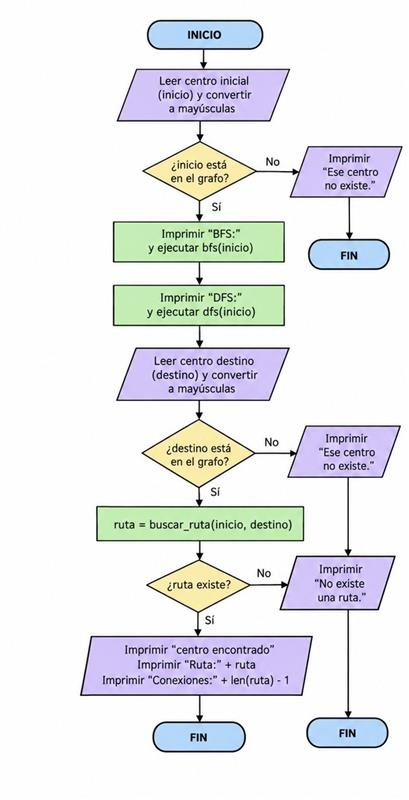


## 5) Diagramas de secuencia **[5 pts]**


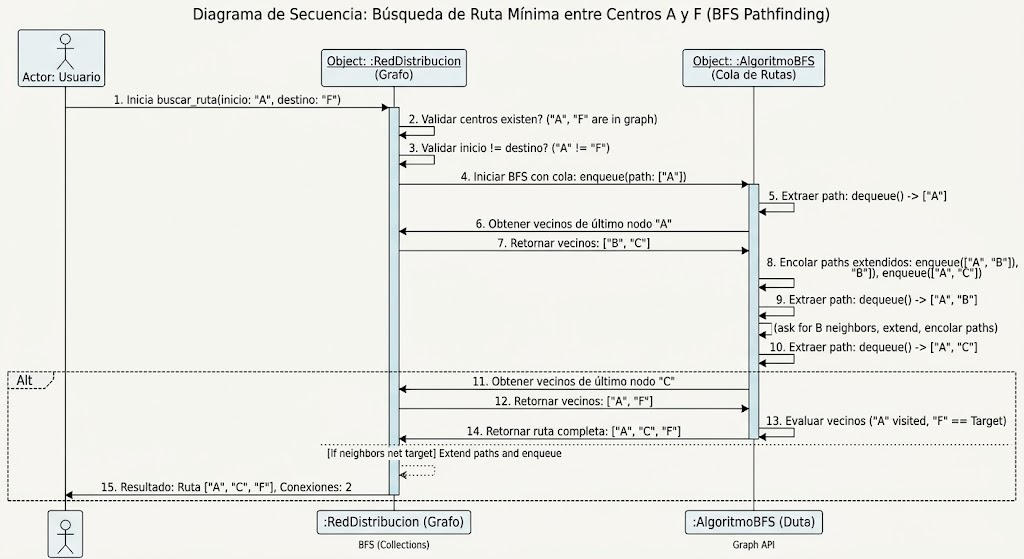

## 6) Código funcional **[15 pts]**



In [ ]:
# Escribe tu código aquí.
from collections import deque

# Grafo
grafo = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "G"],
    "F": ["C", "G"],
    "G": ["E", "F"]
}


# BFS
def bfs(inicio):
    visitados = []
    cola = deque([inicio])

    while cola:
        nodo = cola.popleft()

        if nodo not in visitados:
            visitados.append(nodo)

            for vecino in grafo[nodo]:
                cola.append(vecino)

    return visitados


# DFS
def dfs(inicio):
    visitados = []
    pila = [inicio]

    while pila:
        nodo = pila.pop()

        if nodo not in visitados:
            visitados.append(nodo)

            for vecino in reversed(grafo[nodo]):
                pila.append(vecino)

    return visitados


# Buscar una ruta
def buscar_ruta(inicio, destino):
    cola = deque([[inicio]])

    while cola:
        ruta = cola.popleft()
        nodo = ruta[-1]

        if nodo == destino:
            return ruta

        for vecino in grafo[nodo]:
            if vecino not in ruta:
                nueva_ruta = ruta + [vecino]
                cola.append(nueva_ruta)

    return None


# Programa principal
inicio = input("Ingrese el centro inicial: ").upper()

if inicio not in grafo:
    print("Ese centro no existe.")

else:
    print("\nBFS:")
    print(" -> ".join(bfs(inicio)))

    print("\nDFS:")
    print(" -> ".join(dfs(inicio)))

    destino = input("\nIngrese el centro que desea buscar: ").upper()

    if destino not in grafo:
        print("Ese centro no existe.")
    else:
        ruta = buscar_ruta(inicio, destino)

        if ruta:
            print("\nCentro encontrado")
            print("Ruta:", " -> ".join(ruta))
            print("Conexiones:", len(ruta) - 1)
        else:
            print("No existe una ruta.")



Ingrese el centro inicial: C

BFS:
C -> A -> F -> B -> G -> D -> E

DFS:
C -> A -> B -> D -> E -> G -> F

Ingrese el centro que desea buscar: G

Centro encontrado
Ruta: C -> F -> G
Conexiones: 2


## 7) Tests aplicados **[15 pts]**

In [ ]:
# Pruebas con assert

assert bfs("A") == ["A", "B", "C","D", "E", "F", "G"]

assert dfs("A") == ["A", "B", "D", "E", "G", "F", "C"]

assert buscar_ruta("A", "G") == ["A", "B", "E", "G"]

assert buscar_ruta("A", "A") == ["A"]

print("Todas las pruebas pasaron correctamente.")


Todas las pruebas pasaron correctamente.


## Pruebas de enunciado

¿Qué va aquí?

Casos de prueba proporcionados por el enunciado.

Entrada usada.

Salida esperada.

Salida obtenida.

In [ ]:
# 1: Recorrido BFS desde el centro 'C'
assert bfs("C") == ["C", "A", "F", "B", "G", "D", "E"]

# 2: Recorrido DFS desde el centro 'A' (utilizando Pila e inversión reversed)
assert dfs("A") == ["A", "B", "D", "E", "G", "F", "C"]

# 3: Búsqueda de la ruta más corta desde 'A' hasta 'G' mediante BFS
assert buscar_ruta("A", "G") == ["A", "B", "E", "G"]

print("✓ Todas las pruebas de enunciado pasaron exitosamente.")

✓ Todas las pruebas de enunciado pasaron exitosamente.


## Pruebas propias
¿Qué va aquí?

Casos creados por usted.

Casos tomados de [UDebug](https://www.udebug.com/) (si aplica).


In [ ]:
def agregar_centro(nuevo, conexiones):
    if nuevo not in grafo:
        grafo[nuevo] = []
    for c in conexiones:
        if c in grafo:
            if c not in grafo[nuevo]:
                grafo[nuevo].append(c)
            if nuevo not in grafo[c]:
                grafo[c].append(nuevo)

# # 1: Ruta donde origen y destino son el mismo nodo
assert buscar_ruta("A", "A") == ["A"]

# # 2: Recorridos BFS y DFS partiendo de un nodo periférico ('D')
assert bfs("D") == ["D", "B", "A", "E", "C", "G", "F"]
assert dfs("D") == ["D", "B", "A", "C", "F", "G", "E"]

# # 3: Expansión de la red agregando un nuevo centro 'H' conectado a 'G'
agregar_centro("H", ["G"])
assert "H" in grafo["G"]
assert "G" in grafo["H"]
assert buscar_ruta("A", "H") == ["A", "B", "E", "G", "H"]

# # 4: Búsqueda de ruta hacia un centro inexistente en la red
assert buscar_ruta("A", "Z") is None

print("✓ Todas las pruebas propias pasaron exitosamente.")

✓ Todas las pruebas propias pasaron exitosamente.


## Pruebas de Desempeño
Qué va aquí?

Medición empírica del tiempo de ejecución.

Gráfica de comportamiento.

Relación entre la gráfica obtenida y el análisis de complejidad teórico.

#### Código base para benchmarking

Generando datos .......................

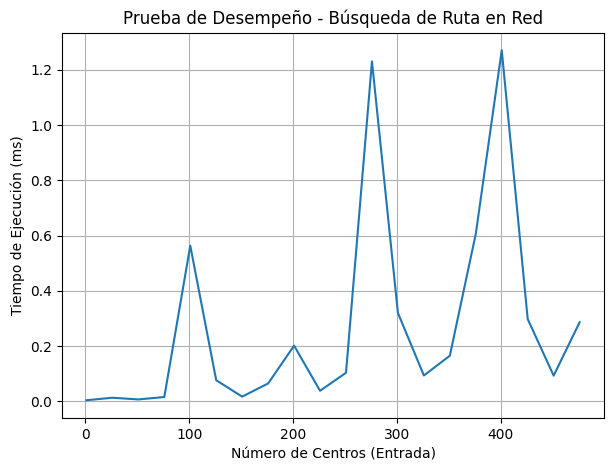

In [ ]:
from collections import deque
import random
import time
import matplotlib.pyplot as plt

def buscar_ruta(inicio, destino, grafo_input):
    cola = deque([[inicio]])

    while cola:
        ruta = cola.popleft()
        nodo = ruta[-1]

        if nodo == destino:
            return ruta

        for vecino in grafo_input[nodo]:
            if vecino not in ruta:
                nueva_ruta = ruta + [vecino]
                cola.append(nueva_ruta)

    return None

def bench(n: int, step: int = 1) -> list[tuple[int, float]]:
    print("Generando datos ...", end="")
    results: list[tuple[int, float]] = []

    for size in range(1, n, step):
        grafo_test = {i: [] for i in range(size)}
        for i in range(size):
            for _ in range(3):
                vecino = random.randint(0, size - 1)
                if vecino != i:
                    if vecino not in grafo_test[i]:
                        grafo_test[i].append(vecino)
                    if i not in grafo_test[vecino]:
                        grafo_test[vecino].append(i)

        ti = time.perf_counter()
        output = buscar_ruta(0, size - 1, grafo_test)
        tf = time.perf_counter()
        delta = (tf - ti) * 1000
        print(".", end="")
        results.append((size, delta))

    return results


def dibujar(x, y, dimensiones=(7, 5)):
    assert len(x) == len(y)

    plt.figure(figsize=dimensiones)
    plt.plot(x, y)
    plt.title("Prueba de Desempeño - Búsqueda de Ruta en Red")
    plt.xlabel("Número de Centros (Entrada)")
    plt.ylabel("Tiempo de Ejecución (ms)")
    plt.grid(True)
    plt.show()



tiempos = bench(500, step=25)

x = [size for size, timing in tiempos]
y = [timing for size, timing in tiempos]

dibujar(x, y)